<a href="https://colab.research.google.com/github/angelrecalde2024/Power-System-Planning-and-Transmission-Design-2026/blob/main/INGP1118_ScreeningCurve_GenPlan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SCREENING CURVE METHOD

Screening curves are a static, long-run equilibrium approximation to determine:


*   Which tecnologies should serve base load
*   Which should serve mid-merit
*   Which should serve peak

The question that Screening Curve Analysis answer is: Given technology cost structures (fixed+variable), and given the system load duration curve (LDC), what is the economically optimal mix of capacities?

This method do this without: Production simulation, Unit Commitment, Optimal Power Flow, Stochastic Optimization. **We assume that all load is served by new candidate technologies. The screening-curve + LDC projection gives an 'optimal' mix accross the full LDC.**  

The Screening Curves work in the following way:


1.   Compute annualized fixed cost per MW
2.   Compute variable cost per MWh
3.   Plot total cost vs capacity factor (or hours)
4.   Find intersections between technologies
5.   Project those intersections hours onto the Load Duration Curve (LDC)
6.   Determine optimal MW blocks

The Screening Curves Method helps in visualizing: 1) capital vs fuel trade-off, 2) why nuclear/coal serve base, 3) why gas turbines serves peak, 4) why CCGT sits in the middle. It gives the optimal mix without solving an optimization problem.






=== Screening Curve Parameters (per technology) ===
   Unit           Tech  LifetimeYears  DiscountRate  EscalationRate  FixedChargeRate       LF  F_fixed_$/MWyr  V_slope_$/MWh  VarCost_$/MWh_base  VarCost_$/MWh_levelized
UNIT 1  Combined Cycle             20          0.10            0.06              0.2 1.536606   330732.121416      36.878546               24.00                36.878546
 UNIT 2     Coal fired             25          0.12            0.06              0.2 1.588518   434296.660348      23.430638               14.75                23.430638
 UNIT 3    Gas turbine             22          0.10            0.06              0.2 1.588432    71588.432365     111.190266               70.00               111.190266

=== Breakpoints (hours where cheapest technology changes) ===
  h*=3,487.3 hours: switch UNIT 3 -> UNIT 1 
  h*=7,701.2 hours: switch UNIT 1  -> UNIT 2

=== Approx. Optimal Capacity Blocks from LDC Projection (MW) ===
 Segment    FromHour      ToHour  LoadFrom_MW   L

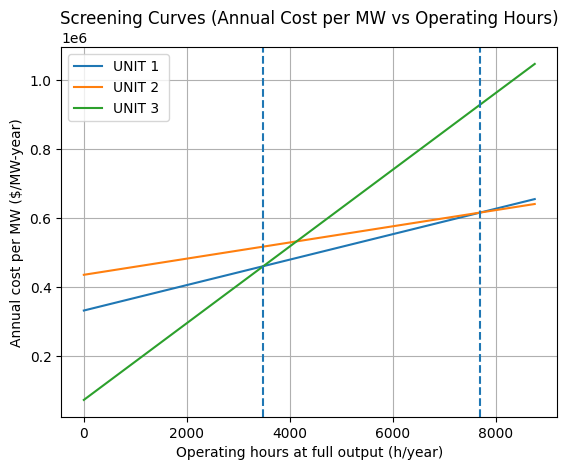

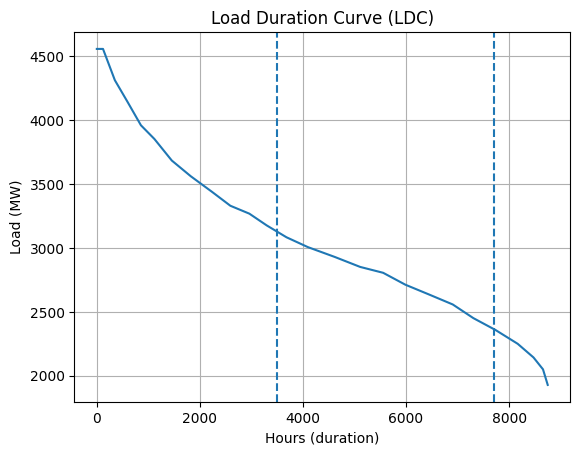


Saved for future cells: df_params, df_ldc, envelope, breakpoints, mix_df, screening_state


In [1]:
# ============================================================
# Screening Curve Analysis (Greenfield) using Excel sheets:
#   - "Units": technology cost/finance inputs (one row per candidate)
#   - "LDC"  : real Load Duration Curve points (Hour, Power (MW))
#
# Output:
#   1) Screening-curve parameters per technology (Fixed intercept and variable slope)
#   2) Lower-envelope (cheapest technology by operating hours)
#   3) Break-even hours between chosen technologies
#   4) Approx. optimal MW mix by projecting break-even hours onto the LDC
#   5) Plots: Screening curves + LDC with breakpoints
#
# IMPORTANT ASSUMPTION (matches your earlier levelizing workflow):
#   - Fuel + both O&M components are escalated and "levelized" using LF(i,a,n).
#   - Owning cost uses the GIVEN FixedChargeRate (already "levelized" per your notes).
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# User settings
# -------------------------
excel_path = "/content/GenDataForGenExpansionPlan.xlsx"  # <-- adjust if needed
units_sheet = "Units"
ldc_sheet = "LDC"

# If your LDC ends at < 8760 (e.g., 8750), we will treat the final point as representative near year end.
HOURS_YEAR = 8760.0

# -------------------------
# Finance helpers
# -------------------------
def crf(i: float, n: int) -> float:
    """Capital Recovery Factor: converts present worth to equivalent uniform annual series."""
    if i == 0:
        return 1.0 / n
    return (i * (1 + i) ** n) / ((1 + i) ** n - 1)

def levelizing_factor(i: float, a: float, n: int) -> float:
    """
    Levelizing factor LF = A / C1 for an escalating end-of-year series:
      C_t = C1*(1+a)^(t-1) for t=1..n
    LF = CRF(i,n) * [1 - ((1+a)/(1+i))^n] / (i - a)   (i != a)
    """
    if n <= 0:
        raise ValueError("LifetimeYears (n) must be > 0.")
    if i == a:
        # limit case (rare): PW = C1*n/(1+i), so LF = (n/(1+i))*CRF(i,n)
        return (n / (1 + i)) * crf(i, n)
    ratio = (1 + a) / (1 + i)
    pw_multiplier = (1 - ratio**n) / (i - a)  # PW = C1 * pw_multiplier
    return crf(i, n) * pw_multiplier

def heat_rate_mmbtu_per_mwh(heat_rate_btu_per_kwh: float) -> float:
    """Convert Btu/kWh to MMBtu/MWh. Example: 9500 -> 9.5"""
    return heat_rate_btu_per_kwh / 1000.0

# -------------------------
# LDC helpers
# -------------------------
def prepare_ldc(df_ldc: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure LDC has columns: Hour, Power (MW)
    and is sorted by Hour ascending, with Power non-increasing.
    Adds a (0, peak) point if missing.
    """
    df = df_ldc.copy()
    if "Hour" not in df.columns:
        raise ValueError("LDC sheet must contain a column named 'Hour'.")
    # Accept either "Power (MW)" or "Power" as column name
    power_col = None
    for c in df.columns:
        if str(c).strip().lower() in ["power (mw)", "power", "load (mw)", "mw"]:
            power_col = c
            break
    if power_col is None:
        raise ValueError("LDC sheet must contain a power column (e.g., 'Power (MW)').")

    df = df.rename(columns={power_col: "Power_MW"})
    df["Hour"] = pd.to_numeric(df["Hour"], errors="raise")
    df["Power_MW"] = pd.to_numeric(df["Power_MW"], errors="raise")

    # Sort by hour ascending (x-axis of LDC)
    df = df.sort_values("Hour").reset_index(drop=True)

    # Add hour=0 point if not present (use maximum power as peak)
    if df.loc[0, "Hour"] > 0:
        peak = df["Power_MW"].max()
        df = pd.concat([pd.DataFrame({"Hour": [0.0], "Power_MW": [peak]}), df], ignore_index=True)

    # Make sure hour does not exceed 8760 by a lot (small deviations are fine)
    if df["Hour"].max() > HOURS_YEAR * 1.01:
        raise ValueError("LDC hours exceed ~8760; please check the LDC sheet.")

    # Ensure monotone non-increasing in power (if not, we can enforce by cumulative max from end)
    # Here we warn but do not silently modify unless necessary.
    if not np.all(np.diff(df["Power_MW"].values) <= 1e-9):
        # Enforce a valid LDC shape (non-increasing) to avoid weird projections.
        df["Power_MW"] = np.maximum.accumulate(df["Power_MW"].values[::-1])[::-1]

    return df

def ldc_power_at_hour(df_ldc: pd.DataFrame, h: float) -> float:
    """
    Interpolate load (MW) at a given 'duration' hour h on the LDC.
    - h=0 corresponds to peak load.
    - h increases to ~8760.
    Uses linear interpolation over provided points.
    """
    h = float(np.clip(h, df_ldc["Hour"].min(), df_ldc["Hour"].max()))
    return float(np.interp(h, df_ldc["Hour"].values, df_ldc["Power_MW"].values))

# -------------------------
# Screening curve construction
# -------------------------
def build_screening_params(df_units: pd.DataFrame) -> pd.DataFrame:
    """
    From Units input, compute for each technology k:
      - LF_k (levelizing factor using i, a, n)
      - Fixed intercept F_k ($/MW-year) = CAPEX*FCR + LF*FixedOM
      - Variable slope  V_k ($/MWh)     = LF*(Fuel+VarOM)
    Screening curve:
      C_k(h) = F_k + V_k * h    [$ per MW-year], where h is operating hours at full output.

    NOTE: We use per-MW-year curves (standard for screening curves).
    """
    df = df_units.copy()

    required = [
        "Unit", "LifetimeYears", "DiscountRate", "EscalationRate", "FixedChargeRate",
        "HeatRate_BtuPerkWh", "FuelCost_$/MMBtu", "PlantCost_$/kW",
        "FixedOM_$/kWyr", "VarOM_$/MWh"
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Units sheet missing columns: {missing}")

    # Compute LF per unit
    df["LF"] = [
        levelizing_factor(float(i), float(a), int(n))
        for i, a, n in zip(df["DiscountRate"], df["EscalationRate"], df["LifetimeYears"])
    ]

    # Variable cost base ($/MWh): fuel + variable O&M
    df["HR_MMBtu_per_MWh"] = df["HeatRate_BtuPerkWh"].apply(heat_rate_mmbtu_per_mwh)
    df["FuelCost_$/MWh_base"] = df["HR_MMBtu_per_MWh"] * df["FuelCost_$/MMBtu"]
    df["VarCost_$/MWh_base"] = df["FuelCost_$/MWh_base"] + df["VarOM_$/MWh"]

    # Apply levelizing factor to variable costs (per your assumption)
    df["VarCost_$/MWh_levelized"] = df["LF"] * df["VarCost_$/MWh_base"]

    # Fixed cost intercept per MW-year:
    # CAPEX owning component: (PlantCost $/kW)*1000 kW/MW * FCR
    df["AnnualOwning_$/MWyr"] = df["PlantCost_$/kW"] * 1000.0 * df["FixedChargeRate"]

    # Fixed O&M is annual ($/kW-yr); apply LF; then convert to $/MW-yr
    df["FixedOM_$/MWyr_levelized"] = df["LF"] * df["FixedOM_$/kWyr"] * 1000.0

    # Screening intercept and slope
    df["F_fixed_$/MWyr"] = df["AnnualOwning_$/MWyr"] + df["FixedOM_$/MWyr_levelized"]
    df["V_slope_$/MWh"] = df["VarCost_$/MWh_levelized"]

    return df

def cost_per_mwyr(F_fixed: float, V_slope: float, h: float) -> float:
    """Screening curve: annual cost per MW-year if the plant runs h hours at full output."""
    return F_fixed + V_slope * h

def lower_envelope(df_params: pd.DataFrame, h_grid: np.ndarray) -> pd.DataFrame:
    """
    Evaluate all technologies on an hours grid and identify the cheapest technology at each h.
    Returns a dataframe with columns: Hour, CheapestUnit, MinCost
    """
    units = df_params["Unit"].astype(str).tolist()
    F = df_params["F_fixed_$/MWyr"].values.astype(float)
    V = df_params["V_slope_$/MWh"].values.astype(float)

    costs = np.vstack([cost_per_mwyr(Fk, Vk, h_grid) for Fk, Vk in zip(F, V)])  # shape: (K, len(h_grid))
    idx = np.argmin(costs, axis=0)
    min_cost = costs[idx, np.arange(costs.shape[1])]

    return pd.DataFrame({
        "Hour": h_grid,
        "CheapestUnit": [units[i] for i in idx],
        "MinCost_$/MWyr": min_cost
    })

def compute_breakpoints(df_params: pd.DataFrame, envelope: pd.DataFrame) -> list:
    """
    From the envelope (cheapest unit by hour), compute breakpoints where the cheapest technology changes.
    Each breakpoint is an hour h* where two technologies have equal cost.
    We refine breakpoints by solving:
       F1 + V1*h = F2 + V2*h  -> h = (F2 - F1)/(V1 - V2)
    """
    # Identify segments of constant cheapest unit
    env = envelope.copy()
    changes = env["CheapestUnit"].ne(env["CheapestUnit"].shift()).fillna(True)
    segment_starts = env.loc[changes, ["Hour", "CheapestUnit"]].reset_index(drop=True)

    # If only one technology is cheapest for all hours, no breakpoints
    if len(segment_starts) <= 1:
        return []

    # Map for quick access to F and V by unit name
    map_F = dict(zip(df_params["Unit"].astype(str), df_params["F_fixed_$/MWyr"].astype(float)))
    map_V = dict(zip(df_params["Unit"].astype(str), df_params["V_slope_$/MWh"].astype(float)))

    breakpoints = []
    for s in range(len(segment_starts) - 1):
        u1 = segment_starts.loc[s, "CheapestUnit"]
        u2 = segment_starts.loc[s + 1, "CheapestUnit"]
        F1, V1 = map_F[u1], map_V[u1]
        F2, V2 = map_F[u2], map_V[u2]

        # Solve equality (handle near-parallel lines)
        denom = (V1 - V2)
        if abs(denom) < 1e-12:
            # Parallel lines; breakpoint undefined. Skip.
            continue

        h_star = (F2 - F1) / denom
        # Clamp to feasible hours
        h_star = float(np.clip(h_star, 0.0, HOURS_YEAR))
        breakpoints.append((h_star, u1, u2))

    # Sort by hour
    breakpoints.sort(key=lambda x: x[0])
    return breakpoints

def project_to_ldc(df_ldc: pd.DataFrame, breakpoints: list) -> pd.DataFrame:
    """
    Project breakpoints (hours) onto the LDC to estimate capacity blocks.

    Let L(h) = load (MW) at duration h.
    Define:
      h0 = 0
      h1, h2, ..., hm = breakpoints hours (sorted)
      L0 = L(h0) (peak)
      L1 = L(h1), L2 = L(h2), ...

    Capacity blocks (MW):
      Block 1 (peaker):  L0 - L1
      Block 2 (mid):     L1 - L2
      ...
      Last block (base): Lm

    We also label blocks by the cheapest technology on each interval (using envelope logic).
    """
    # Make sure breakpoints are sorted and unique-ish
    h_list = [0.0] + [bp[0] for bp in breakpoints if 0.0 <= bp[0] <= HOURS_YEAR]
    h_list = sorted(list(dict.fromkeys([round(h, 6) for h in h_list])))  # unique

    # Append end hour for completeness
    if h_list[-1] < df_ldc["Hour"].max():
        h_list.append(float(df_ldc["Hour"].max()))

    # Compute loads at each breakpoint hour
    L = [ldc_power_at_hour(df_ldc, h) for h in h_list]

    # Determine block sizes
    blocks = []
    for k in range(len(h_list) - 1):
        hA, hB = h_list[k], h_list[k + 1]
        LA, LB = L[k], L[k + 1]
        cap_block = max(LA - LB, 0.0)  # MW

        blocks.append({
            "Segment": k + 1,
            "FromHour": hA,
            "ToHour": hB,
            "LoadFrom_MW": LA,
            "LoadTo_MW": LB,
            "CapacityBlock_MW": cap_block
        })

    # Last/base block is the remaining load at the end hour (LB at final point)
    # (Already included as the last segment's LoadTo; capacity at tail is L_end)
    # If you want an explicit base block at the end:
    base_mw = L[-1]
    blocks.append({
        "Segment": len(h_list),
        "FromHour": h_list[-1],
        "ToHour": HOURS_YEAR,
        "LoadFrom_MW": L[-1],
        "LoadTo_MW": 0.0,
        "CapacityBlock_MW": base_mw
    })

    return pd.DataFrame(blocks)

# -------------------------
# MAIN: Read Excel and run screening curve analysis
# -------------------------
df_units = pd.read_excel(excel_path, sheet_name=units_sheet)
df_ldc_raw = pd.read_excel(excel_path, sheet_name=ldc_sheet)

df_ldc = prepare_ldc(df_ldc_raw)
df_params = build_screening_params(df_units)

# Hours grid for envelope evaluation (fine grid improves breakpoint detection)
h_grid = np.linspace(0.0, HOURS_YEAR, 2001)

envelope = lower_envelope(df_params, h_grid)
breakpoints = compute_breakpoints(df_params, envelope)

# Project breakpoints to LDC -> approximate MW mix
mix_df = project_to_ldc(df_ldc, breakpoints)

# -------------------------
# Report tables
# -------------------------
print("=== Screening Curve Parameters (per technology) ===")
cols_show = [
    "Unit", "Tech", "LifetimeYears", "DiscountRate", "EscalationRate", "FixedChargeRate",
    "LF", "F_fixed_$/MWyr", "V_slope_$/MWh", "VarCost_$/MWh_base", "VarCost_$/MWh_levelized"
]
# Keep only columns that exist (Tech might exist in your Excel; otherwise it will be skipped)
cols_show = [c for c in cols_show if c in df_params.columns]
print(df_params[cols_show].to_string(index=False))

print("\n=== Breakpoints (hours where cheapest technology changes) ===")
if not breakpoints:
    print("No breakpoints found: one technology dominates for all operating hours.")
else:
    for h_star, u1, u2 in breakpoints:
        print(f"  h*={h_star:,.1f} hours: switch {u1} -> {u2}")

print("\n=== Approx. Optimal Capacity Blocks from LDC Projection (MW) ===")
print(mix_df.to_string(index=False))

# Rank technologies by:
# - Intercept (fixed cost): small intercept favors peaking
# - Slope (variable cost): small slope favors baseload
print("\n=== Quick intuition checks ===")
print("Lower intercept => good peaker candidate; lower slope => good baseload candidate.\n")
print(df_params[["Unit", "F_fixed_$/MWyr", "V_slope_$/MWh"]].sort_values("F_fixed_$/MWyr").to_string(index=False))

# -------------------------
# Plots (Screening curves + LDC)
# -------------------------
# 1) Screening curves: cost per MW-year vs hours
plt.figure()
for _, r in df_params.iterrows():
    Fk = float(r["F_fixed_$/MWyr"])
    Vk = float(r["V_slope_$/MWh"])
    plt.plot(h_grid, Fk + Vk * h_grid, label=str(r["Unit"]))
plt.xlabel("Operating hours at full output (h/year)")
plt.ylabel("Annual cost per MW ($/MW-year)")
plt.title("Screening Curves (Annual Cost per MW vs Operating Hours)")
plt.legend()
plt.grid(True)

# Mark breakpoints
for h_star, _, _ in breakpoints:
    plt.axvline(h_star, linestyle="--")

# 2) LDC: load vs hour (duration)
plt.figure()
plt.plot(df_ldc["Hour"], df_ldc["Power_MW"])
plt.xlabel("Hours (duration)")
plt.ylabel("Load (MW)")
plt.title("Load Duration Curve (LDC)")
plt.grid(True)

# Mark projected breakpoint hours on LDC
for h_star, _, _ in breakpoints:
    plt.axvline(h_star, linestyle="--")

plt.show()

# -------------------------
# Save objects for future cells
# -------------------------
screening_state = {
    "excel_path": excel_path,
    "df_units": df_units,
    "df_params": df_params,         # includes LF, intercept F, slope V
    "df_ldc": df_ldc,
    "h_grid": h_grid,
    "envelope": envelope,
    "breakpoints": breakpoints,
    "mix_df": mix_df
}

print("\nSaved for future cells: df_params, df_ldc, envelope, breakpoints, mix_df, screening_state")

SCREENING CURVE WITH EXISTING MUST-RUN HYDRO

Existing hydro already supplies part of the load (typically low marginal cost, often dispatched whenever available). In screening curve terms, it occupies the bottom of the LDC (base energy and possibly some capacity), so new builds compete only for the residual demand. The, we perform screening curve sizing on residual LDC instead of original LDC. The optimal mix changes because,


*   Peak may be reduced (if hydro contributes at peak hours)
*   Base portion may be reduced strongly (hydro usually contributes many hours)
*   Intersection projections onto the residual LDC yield different MW blocks

Must-run hydro can mean:


1.   Constant musr-run MW
2.   Seasonal/variable hydro output
3.   Energy-limited hydro (constrained by annual water availability)

**For screening curve with residual LDC, we need hydro represented as a duration curve of must-run MW, even if it's a simple constant.**

The screening envelope depends only on technology costs, not on the LDC. What changes with hydro is the projection onto the LDC, which we do with 'project_to_ldc(df_ldc_res, breakpoints_res)'.

If hydro is larger that load for significant hours, that would imply spill/curtailment and changes the 'must-run' assumption.

In the Excel sheet 'ExistingUnits', we must edit the Mode column to work in any of both ways:

UNIT,     TYPE,     MODE,     CurveSheet

Hydro1,   Hydro,    Curve (or Constant),    HydroLCD

Constant Mode subtracts fixed MW from LDC, and Curve Mode reads HydroLDC sheet and interpolates.

FOR FUTURE
We can add:

*   Hydro installed capacity limit
*   Turbine efficiency varying with load
*   Hydro energy constraints














=== Existing Hydro Must-Run Summary ===
         Unit  Mode  MustRunMW
Hydro_mustRun Curve        950

=== LDC Peak Comparison ===
Original peak load: 4,559.0 MW
Residual peak load: 3,584.8 MW
Hydro must-run (at LDC points): min=50.9 MW, max=1,054.1 MW

=== Breakpoints on RESIDUAL LDC ===
  h*=3,487.3 hours: switch UNIT 3 -> UNIT 1 
  h*=7,701.2 hours: switch UNIT 1  -> UNIT 2

=== Approx. Optimal Capacity Blocks from RESIDUAL LDC Projection (MW) ===
 Segment    FromHour      ToHour  LoadFrom_MW   LoadTo_MW  CapacityBlock_MW
       1    0.000000 3487.251939  3584.756517 2912.195188        672.561329
       2 3487.251939 7701.163604  2912.195188 2277.308659        634.886529
       3 7701.163604 8750.000000  2277.308659 1877.140325        400.168334
       4 8750.000000 8760.000000  1877.140325    0.000000       1877.140325


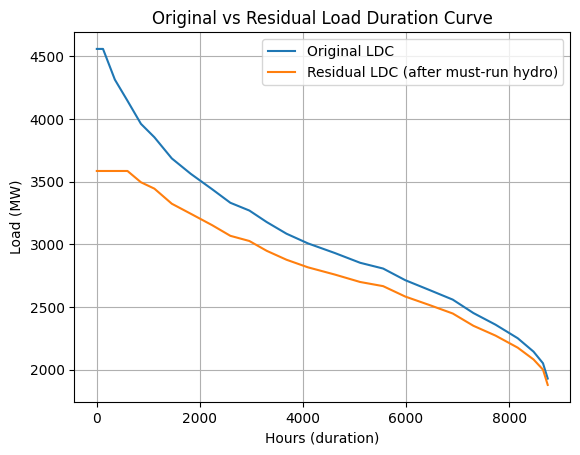

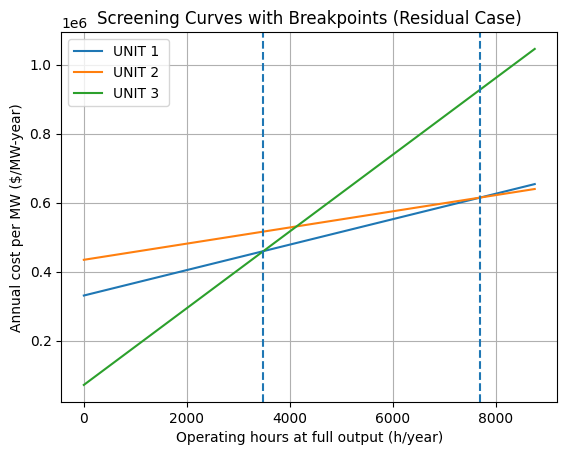


Saved for future cells: df_ldc_res, envelope_res, breakpoints_res, mix_df_res, residual_state


In [7]:
# ============================================================
# Residual LDC with existing must-run hydro
# Reads a new Excel sheet: "ExistingUnits"
#   - Mode = "Constant": MustRunMW is constant for all hours
# (Optionally extend later to Mode="Curve" with a HydroLDC sheet.)
#
# Output:
#   - residual LDC (df_ldc_res)
#   - new screening results on residual demand:
#       envelope_res, breakpoints_res, mix_df_res
#   - plots comparing original vs residual LDC
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# User settings
# -------------------------
existing_sheet = "ExistingUnits"

# If you have multiple existing units, we will sum their must-run contributions.
# For now we focus on must-run hydro, but you can include other must-run types similarly.

# --- Hydro conversion assumptions (edit freely) ---
hydro_head_m = 150.0         # constant head (m)
hydro_efficiency = 0.90      # overall turbine+generator efficiency (0..1)

hydro_curve_sheet_default = "HydroLDC"  # sheet contains FDC: % exceedance vs flow

# -------------------------
# Hydro LDC reader + interpolation helpers
# -------------------------
def read_hydro_curve_from_fdc(excel_path: str, sheet_name: str,
                              head_m: float, eta: float,
                              rho: float = 1000.0, g: float = 9.81) -> pd.DataFrame:
    """
    Read a FLOW duration curve (FDC) from Excel and convert it to a HYDRO POWER duration curve.

    Expected columns in HydroLDC sheet (case-insensitive matching supported):
      - '%Exceedance'  (0..100)  OR 'ExceedancePercent'
      - 'Flow_m3s'     (m^3/s)   OR 'Flow (m3/s)' OR similar

    Output dataframe:
      - Hour     (duration hour, 0..8760)
      - Power_MW (duration curve, non-increasing with Hour)
    """
    df_raw = pd.read_excel(excel_path, sheet_name=sheet_name).copy()

    # --- Find exceedance column ---
    exc_col = None
    for c in df_raw.columns:
        c_low = str(c).strip().lower()
        if c_low in ["%exceedance", "exceedancepercent", "exceedance %", "percentexceedance"]:
            exc_col = c
            break
    if exc_col is None:
        raise ValueError(
            f"HydroLDC sheet '{sheet_name}' must contain an exceedance column like '%Exceedance' or 'ExceedancePercent'."
        )

    # --- Find flow column ---
    flow_col = None
    for c in df_raw.columns:
        c_low = str(c).strip().lower()
        if c_low in ["flow_m3s", "flow (m3/s)", "flow m3/s", "flow(m3/s)", "q_m3s", "q (m3/s)"]:
            flow_col = c
            break
    if flow_col is None:
        raise ValueError(
            f"HydroLDC sheet '{sheet_name}' must contain a flow column like 'Flow_m3s' (m^3/s)."
        )

    df = df_raw.rename(columns={exc_col: "ExceedancePercent", flow_col: "Flow_m3s"})
    df["ExceedancePercent"] = pd.to_numeric(df["ExceedancePercent"], errors="raise")
    df["Flow_m3s"] = pd.to_numeric(df["Flow_m3s"], errors="raise")

    # Sanity checks
    if (df["ExceedancePercent"] < 0).any() or (df["ExceedancePercent"] > 100).any():
        raise ValueError("ExceedancePercent must be between 0 and 100.")
    if (df["Flow_m3s"] < 0).any():
        raise ValueError("Flow_m3s must be nonnegative.")
    if not (0 < eta <= 1):
        raise ValueError("hydro_efficiency must be in (0, 1].")
    if head_m <= 0:
        raise ValueError("hydro_head_m must be > 0.")

    # Convert exceedance% to duration hours
    df["Hour"] = (df["ExceedancePercent"] / 100.0) * HOURS_YEAR

    # Convert flow to MW using constant head
    df["Power_MW"] = (rho * g * head_m * eta * df["Flow_m3s"]) / 1e6

    # Sort by Hour ascending
    df = df.sort_values("Hour").reset_index(drop=True)

    # Enforce a valid duration curve: non-increasing Power with increasing Hour
    # (FDCs are typically non-increasing already, but we enforce for robustness.)
    df["Power_MW"] = np.maximum.accumulate(df["Power_MW"].values[::-1])[::-1]

    return df[["Hour", "Power_MW"]]


def hydro_curve_power_at_hour(df_curve: pd.DataFrame, h: float) -> float:
    """Interpolate hydro must-run MW at duration hour h using the converted Hydro power duration curve."""
    h = float(np.clip(h, df_curve["Hour"].min(), df_curve["Hour"].max()))
    return float(np.interp(h, df_curve["Hour"].values, df_curve["Power_MW"].values))


# --- Cache for hydro curves (supports CurveSheet override later) ---
try:
    _hydro_curve_cache
except NameError:
    _hydro_curve_cache = {}

# -------------------------
# Load ExistingUnits
# -------------------------
df_exist = pd.read_excel(excel_path, sheet_name=existing_sheet)

required_cols = ["Unit", "Type", "Mode"]
missing = [c for c in required_cols if c not in df_exist.columns]
if missing:
    raise ValueError(f"ExistingUnits sheet missing columns: {missing}")

# Normalize strings
df_exist["Type"] = df_exist["Type"].astype(str).str.strip()
df_exist["Mode"] = df_exist["Mode"].astype(str).str.strip()

# Filter hydro (you can broaden later if desired)
df_hydro = df_exist[df_exist["Type"].str.lower() == "hydro"].copy()
if df_hydro.empty:
    raise ValueError("No rows with Type='Hydro' found in ExistingUnits sheet.")

# -------------------------
# Build hydro must-run duration curve G_hydro(h)
# -------------------------
def hydro_mustrun_at_hour(h: float) -> float:
    """
    Returns total hydro must-run MW at duration hour h.
    Currently supports:
      - Mode='Constant' with column MustRunMW
      - Mode='Curve' with column CurveSheet
    """
    total = 0.0
    for _, r in df_hydro.iterrows():
        mode = str(r["Mode"]).strip().lower()
        if mode == "constant":
            if "MustRunMW" not in df_hydro.columns:
                raise ValueError("ExistingUnits requires column 'MustRunMW' for Mode='Constant'.")
            total += float(r["MustRunMW"])
        elif mode == "curve":
            # Allow per-row sheet override (optional)
            curve_sheet = hydro_curve_sheet_default
            if "CurveSheet" in df_hydro.columns and pd.notna(r.get("CurveSheet", None)):
                curve_sheet = str(r["CurveSheet"]).strip()

            # Load/cache the hydro POWER duration curve converted from FDC
            if curve_sheet not in _hydro_curve_cache:
                _hydro_curve_cache[curve_sheet] = read_hydro_curve_from_fdc(
                    excel_path=excel_path,
                    sheet_name=curve_sheet,
                    head_m=hydro_head_m,
                    eta=hydro_efficiency
                )

            df_curve = _hydro_curve_cache[curve_sheet]
            total += hydro_curve_power_at_hour(df_curve, h)
        else:
            raise ValueError(f"Unknown Mode='{r['Mode']}'. Use 'Constant' (or later 'Curve').")
    return total

# Vectorize across the LDC hours
hydro_series = np.array([hydro_mustrun_at_hour(h) for h in df_ldc["Hour"].values], dtype=float)

# -------------------------
# Build residual LDC: L_res(h) = max(L(h) - G_hydro(h), 0)
# -------------------------
df_ldc_res = df_ldc.copy()
df_ldc_res["HydroMustRun_MW"] = hydro_series
df_ldc_res["ResidualLoad_MW"] = np.maximum(df_ldc_res["Power_MW"].values - df_ldc_res["HydroMustRun_MW"].values, 0.0)

# Warning if must-run hydro exceeds load (implies curtailment/spill)
exceed = (df_ldc_res["HydroMustRun_MW"] > df_ldc_res["Power_MW"])
if exceed.any():
    frac = exceed.mean()
    print(f"WARNING: Hydro must-run exceeds gross load for {frac:.1%} of LDC points. "
          "Residual is clipped to 0 MW (implies curtailment/spill). "
          "If this is not expected, reduce MustRunMW or use a hydro curve.")

# Replace the "Power_MW" column so we can reuse the same projection functions unchanged
df_ldc_res = df_ldc_res.rename(columns={"Power_MW": "OriginalLoad_MW"})
df_ldc_res["Power_MW"] = df_ldc_res["ResidualLoad_MW"]

# Ensure residual LDC is still non-increasing (numerical safety)
df_ldc_res["Power_MW"] = np.maximum.accumulate(df_ldc_res["Power_MW"].values[::-1])[::-1]

print("=== Existing Hydro Must-Run Summary ===")
print(df_hydro[["Unit", "Mode"] + ([c for c in ["MustRunMW"] if c in df_hydro.columns])].to_string(index=False))
print()
print("=== LDC Peak Comparison ===")
print(f"Original peak load: {df_ldc['Power_MW'].max():,.1f} MW")
print(f"Residual peak load: {df_ldc_res['Power_MW'].max():,.1f} MW")
print(f"Hydro must-run (at LDC points): min={hydro_series.min():,.1f} MW, max={hydro_series.max():,.1f} MW")

# -------------------------
# Rerun screening on residual LDC (same candidate tech data)
# -------------------------
# Reuse: df_params, h_grid, lower_envelope(), compute_breakpoints(), project_to_ldc()

envelope_res = lower_envelope(df_params, h_grid)
breakpoints_res = compute_breakpoints(df_params, envelope_res)
mix_df_res = project_to_ldc(df_ldc_res[["Hour", "Power_MW"]].copy(), breakpoints_res)

print("\n=== Breakpoints on RESIDUAL LDC ===")
if not breakpoints_res:
    print("No breakpoints found on residual case: one technology dominates for all operating hours.")
else:
    for h_star, u1, u2 in breakpoints_res:
        print(f"  h*={h_star:,.1f} hours: switch {u1} -> {u2}")

print("\n=== Approx. Optimal Capacity Blocks from RESIDUAL LDC Projection (MW) ===")
print(mix_df_res.to_string(index=False))

# -------------------------
# Plots: Original vs Residual LDC + Screening curves (optional)
# -------------------------
plt.figure()
plt.plot(df_ldc["Hour"], df_ldc["Power_MW"], label="Original LDC")
plt.plot(df_ldc_res["Hour"], df_ldc_res["Power_MW"], label="Residual LDC (after must-run hydro)")
plt.xlabel("Hours (duration)")
plt.ylabel("Load (MW)")
plt.title("Original vs Residual Load Duration Curve")
plt.grid(True)
plt.legend()
plt.show()

# (Optional) Show screening curves again with residual breakpoints
plt.figure()
for _, r in df_params.iterrows():
    Fk = float(r["F_fixed_$/MWyr"])
    Vk = float(r["V_slope_$/MWh"])
    plt.plot(h_grid, Fk + Vk * h_grid, label=str(r["Unit"]))
for h_star, _, _ in breakpoints_res:
    plt.axvline(h_star, linestyle="--")
plt.xlabel("Operating hours at full output (h/year)")
plt.ylabel("Annual cost per MW ($/MW-year)")
plt.title("Screening Curves with Breakpoints (Residual Case)")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# Save state for future cells (e.g., later add VOLL/LOL, or hydro curve mode)
# -------------------------
residual_state = {
    "df_exist": df_exist,
    "df_hydro": df_hydro,
    "df_ldc_res": df_ldc_res,
    "envelope_res": envelope_res,
    "breakpoints_res": breakpoints_res,
    "mix_df_res": mix_df_res
}

print("\nSaved for future cells: df_ldc_res, envelope_res, breakpoints_res, mix_df_res, residual_state")